- **Import dependencies**

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import optimize

- **Read the data**

In [2]:
# Collect the files globally
files = glob.glob(f"/Users/euanbronsky/Downloads/Options.SPX.20*/*.txt")

# Read the files and concatenate into a dataframe
data = pd.concat([pd.read_csv(file, sep = ',', engine = 'c', low_memory=False) for file in files], ignore_index=True)

- **Preliminary adjustments**

In [3]:
# Clean column names
data.columns = data.columns.str.lower().str.replace(r'[\[\]\s]','', regex=True)

# Adjust columns and keep only relevant columns
relevant_cols = ['quote_date', 'underlying_last', 'expire_date', 'dte', 'c_iv', 'c_bid', 'c_ask', 'c_delta', 'strike', 'p_bid', 'p_ask', 'p_iv', 'p_delta']
data = data[relevant_cols].copy()

# Convert datatypes in one go using assign function
data = data.assign(
    **{col: pd.to_numeric(data[col], errors='coerce')
       for col in ['underlying_last', 'dte', 'c_iv', 'c_bid', 'c_ask', 'c_delta', 'strike', 'p_bid', 'p_ask', 'p_iv', 'p_delta']},
    **{col: pd.to_datetime(data[col], errors='coerce')
       for col in ['quote_date', 'expire_date']})

Separate calls from puts and merge them into a long format dataframe

In [4]:
# Define common columns
common_cols = ['quote_date', 'underlying_last', 'expire_date', 'dte', 'strike']

# Handle calls separately
calls = (data[common_cols + ['c_iv', 'c_bid', 'c_ask', 'c_delta']]
         .rename(columns={'c_bid': 'bid', 'c_ask': 'ask', 'c_iv': 'iv', 'c_delta': 'delta'})
         .assign(option_type = 'call'))

# Separate puts from calls
puts = (data[common_cols + ['p_iv', 'p_bid', 'p_ask', 'p_delta']]
        .rename(columns={'p_bid': 'bid', 'p_ask': 'ask', 'p_iv': 'iv', 'p_delta': 'delta'})
        .assign(option_type = 'put'))

# Concatenate the results and sort values
df = pd.concat([calls, puts], ignore_index=True)
df = df.sort_values(by = ['option_type', 'quote_date', 'expire_date', 'strike'])

# **Cleaning function 1**

- Computation of midquotes $$\text{midquote} = \frac{bid + ask}{2}$$
- Removal of low prices $$\text{midquote} \leq 3/8$$
- Keep only moderate time-to-maturities $$7 \leq \text{TTM} \leq 360 $$
- Remove moderately/deeply ITM options: $$K < 0.97 S_t, \quad K > 1.03 S_t$$

The function includes the number of observations left after removal, the drop count, and percentage drop.

In [5]:
# initial cleaning function
def cleaning_fun(df):

    # Copy the dataframe and initiate dictionary
    df = df.copy()
    stats = {}

    # Initial count
    stats['initial'] = len(df)

    # Step 1: compute mid prices
    df['mid'] = (df['bid'] + df['ask'])/2
    stats['after_mid'] = len(df)

    # Step 2: remove low-priced (DOTM) options
    df = df[df['mid'] >= 3/8]
    stats['after_price'] = len(df)

    # Step 3: removal of very short and long TTM
    df= df[(df['dte'] >= 7) & (df['dte'] <= 360)]
    stats['after_ttm'] = len(df)

    # Step 4: removal of ITM options
    df = df[((df['option_type'] == 'call') & (df['strike'] >= 0.97 * df['underlying_last'])) | ((df['option_type'] == 'put') & (df['strike'] <= 1.03 * df['underlying_last']))]
    stats['after_moneyness'] = len(df)

    # Convert to dropped counts
    drops = {
        'price_drop': stats['initial'] - stats['after_price'],
        'ttm_drop': stats['after_price'] - stats['after_ttm'],
        'moneyness_drop': stats['after_ttm'] - stats['after_moneyness']}

    # Convert to percentage dropped
    percent_drops = {
        'price_drop_pct': (drops['price_drop'] / stats['initial']) * 100,
        'ttm_drop_pct': (drops['ttm_drop'] / stats['after_price']) * 100,
        'moneyness_drop_pct': (drops['moneyness_drop'] / stats['after_ttm']) * 100}

    # Return the dataframe
    return df, stats, drops, percent_drops

- **Apply the cleaning function**

In [6]:
# Apply the function
df1, stats, drops, percent_drops = cleaning_fun(df)

# Create dataframe with statistics and print
df1_stats = pd.DataFrame({
    'step': ['price', 'ttm', 'moneyness'],
    'remaining': [
        stats['after_price'],
        stats['after_ttm'],
        stats['after_moneyness']],
    'dropped': [
        drops['price_drop'],
        drops['ttm_drop'],
        drops['moneyness_drop']],
    'pct_drop': [
        percent_drops['price_drop_pct'],
        percent_drops['ttm_drop_pct'],
        percent_drops['moneyness_drop_pct']]})
df1_stats

,step,remaining,dropped,pct_drop
0,price,27690773,3422181,10.999216
1,ttm,23331733,4359040,15.741850
2,moneyness,12600425,10731308,45.994475


# **Risk-free rate**

- **Read the data**

In [7]:
# Import the treasury data
rf_data = pd.read_csv('/Users/euanbronsky/Downloads/yield-curve-rates-1990-2023.csv')

In [8]:
# Convert to datetime, reverse index, and reset index
rf_data = (rf_data
           .assign(Date = pd.to_datetime(rf_data['Date'], errors='coerce', format='%m/%d/%y'))
           .iloc[::-1]
           .reset_index(drop=True))

# Adjust the columns
rf_data.columns = rf_data.columns.str.lower().str.replace(r'\s', '', regex=True)

# Operationalize the rates and compute T in the original DF
cols = rf_data.columns.drop('date')
rf_data[cols] = rf_data[cols] / 100
df1['T'] = df1['dte'] / 365

In [9]:
# Merge the dataframes
df1 = df1.reset_index(drop=True)
aux_df = df1.merge(rf_data[['date'] + cols.tolist()], left_on='quote_date', right_on = 'date', how='left')

# Approximate the closest maturity
df1['r'] = np.select([
    df1['dte'] <= 45,
    df1['dte'] <= 75,
    df1['dte'] <= 105,
    df1['dte'] <= 150,
    df1['dte'] <= 270],
[
    aux_df['1mo'],
    aux_df['2mo'].fillna(aux_df['1mo']).fillna(aux_df['3mo']),
    aux_df['3mo'],
    aux_df['4mo'].fillna(aux_df['3mo']).fillna(aux_df['6mo']),
    aux_df['6mo']], default = aux_df['1yr'])

# **No-arbitrage filtering**

- **Filter function**

In [10]:
# Arbitrage filter
def arbitrage_filter(df1, run_bounds=True):

    # Copy dataframe
    df1 = df1.copy()

    # Initiate dictionary
    stats = {}
    stats['initial'] = len(df1)

    # If statement
    if run_bounds:

        # Step 1a: Put and call lower bounds
        df1 = df1[((df1['option_type'] == 'call') & (df1['mid'] >= np.maximum(df1['underlying_last'] - df1['strike']*np.exp(-df1['r']*df1['dte']/365),0)) | (df1['option_type'] == 'put') & (df1['mid'] >= np.maximum(df1['strike']*np.exp(-df1['r']*df1['dte']/365) - df1['underlying_last'], 0)))]

        # Step 1b: Put and call upper bounds
        df1 = df1[((df1['option_type'] == 'call') & (df1['mid'] <= df1['underlying_last'])) | (df1['option_type'] == 'put') & (df1['mid'] <= df1['strike']*np.exp(-df1['r']*df1['dte']/365))]

    stats['after_bounds'] = len(df1)

    # Sort by strike
    df1 = df1.sort_values(['option_type', 'quote_date', 'expire_date', 'strike'])

    # Step 2: Monotonicity in strike
    diffs = df1.groupby(['option_type', 'quote_date', 'expire_date'])['mid'].diff()
    df1 = df1[((df1['option_type'] == 'call') & (diffs.isna() | (diffs <= 0))) | ((df1['option_type'] == 'put') & (diffs.isna() | (diffs >= 0)))]
    stats['after_strike_mono'] = len(df1)

    # Step 3: Strike convexity
    slopes = (df1.groupby(['option_type', 'quote_date', 'expire_date'])['mid'].diff() / df1.groupby(['option_type', 'quote_date', 'expire_date'])['strike'].diff())
    slope_diffs = slopes.groupby([df1['option_type'], df1['quote_date'], df1['expire_date']]).diff()
    df1 = df1[slope_diffs.isna() | (slope_diffs >= 0)]
    stats['after_strike_convex'] = len(df1)

    # Step 4: Calendar monotonicity
    df1 = df1.sort_values(['option_type', 'quote_date', 'strike', 'dte'])
    diffs_ttm = df1.groupby(['option_type', 'quote_date', 'strike'])['mid'].diff()
    df1 = df1[diffs_ttm.isna() | (diffs_ttm >= 0)]
    stats['after_calendar_mono'] = len(df1)

    # Re-sort the dataframe and reset the index
    df1 = (df1
           .sort_values(['option_type', 'quote_date', 'expire_date', 'strike'])
           .reset_index(drop=True))

    # Compute number drops per steps
    drops = {
        'ub_lb_drop': stats['initial'] - stats['after_bounds'],
        'strike_mono_drop': stats['after_bounds'] - stats['after_strike_mono'],
        'convexity_drop': stats['after_strike_mono'] - stats['after_strike_convex'],
        'calendar_mono_drop': stats['after_strike_convex'] - stats['after_calendar_mono'],
    }

    # Compute percentage drops per step
    pct_drops = {
        'bounds_pct': drops['ub_lb_drop'] / stats['initial'] * 100,
        'strike_mono_pct': drops['strike_mono_drop'] / stats['after_bounds'] * 100,
        'strike_convex_pct': drops['convexity_drop'] / stats['after_strike_mono'] * 100,
        'calendar_mono_pct': drops['calendar_mono_drop'] / stats['after_strike_convex'] * 100,
    }

    # Return the results
    return df1, stats, drops, pct_drops

- **Apply the function and display the results**

In [11]:
# Apply the function and retrieve the results
df_help, stats, drops, pct_drops = arbitrage_filter(df1, run_bounds=True)

# Construct dataframe and display
df_arbitrage = pd.DataFrame({
    'Step': ['Bounds', 'Strike_mono', 'Strike_convex', 'Calendar_mono'],
    'Obs. remaining': [
        stats['after_bounds'],
        stats['after_strike_mono'],
        stats['after_strike_convex'],
        stats['after_calendar_mono']],
    'Obs. removed': [
        drops['ub_lb_drop'],
        drops['strike_mono_drop'],
        drops['convexity_drop'],
        drops['calendar_mono_drop']],
    'Pct. removed': [
        pct_drops['bounds_pct'],
        pct_drops['strike_mono_pct'],
        pct_drops['strike_convex_pct'],
        pct_drops['calendar_mono_pct']],
})
df_arbitrage

,Step,Obs. remaining,Obs. removed,Pct. removed
0,Bounds,12433804,166621,1.322344
1,Strike_mono,12221171,212633,1.710120
2,Strike_convex,8370055,3851116,31.511841
3,Calendar_mono,8332565,37490,0.447906


- **Loop until convergence**

In [ ]:
# Initial specifications
prev_len = -1
max_iter = 100
i = 0

# Loop until convergence
while len(df_help) != prev_len and i < max_iter:

    # Set length to dataframe length
    prev_len = len(df_help)

    # Apply the filter without the upper and lower bound steps
    df_help, _, _, _ = arbitrage_filter(df_help, run_bounds=False)

    # Print the iteration number, previous length and current length, and number of observations dropped
    i += 1
    print(i, prev_len, len(df_help), prev_len - len(df_help))

# **Compute Implied Volatility**

**Implied Volatility** is defined as the value of $\sigma$, holding all other inputs fixed, that equates the **Black-Scholes** option price to the observed market price:

$$C_t^{BS}(S_t, K, r, \tau, \sigma_{IV}) = C_t^{mkt}(S_t, K, \tau)$$

This requires the Black-Scholes determined call option and put option values:
$$C_t = S_t \Phi(d_1) - K e^{-r(T-t)} \Phi(d_2)$$
$$P_t = Ke^{-r(T-t)} \Phi(-d_2) - S_t \Phi(-d_1)$$

In [29]:
# Implied volatility function
def implied_vol(T, S, K, r, mkt_price, call = True):

    # Black-Scholes option price function
    def BS_price(sigma):

        # d1 and d2
        d1 = (np.log(S / K) + (r + 0.5* sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)

        # Compute call and put prices
        call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
        put_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

        # Determine whether input is a call or put
        bs_price = call_price if call else put_price

        # Compute distance to the observed market price
        fx = bs_price - mkt_price

        # Return the difference
        return fx

    # Minimize the distance using brentq
    return optimize.brentq(BS_price, 0.001, 10, maxiter=1000)

- **Apply the function**

In [33]:
# Apply the function and store the results
df_help['iv_fun'] = df_help.apply(
    lambda row: implied_vol(
        S=row['underlying_last'],
        K = row['strike'],
        T=row['dte']/365,
        r=row['r'],
        mkt_price=row['mid'],
        call=(row['option_type'] == 'call')), axis=1)

# **Compute Deltas**

$$d_1 = \frac{\log(S_t / K) + (r + 0.5 \sigma^2) (T-t)}{\sigma \sqrt{T-t}}$$

$$\Delta^C_t = \Phi(d_1), \qquad \Delta^P_t = \Delta^C_t - 1$$

In [35]:
# Delta function
def compute_delta(S, K, r, sigma, T, call = True):

    # Compute d1
    d1 = (np.log(S / K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

    # Compute the call and put delta values
    call_delta = norm.cdf(d1)
    put_delta = call_delta - 1

    # Check if a call or put
    delta = call_delta if call else put_delta

    # Return the results
    return delta

- **Apply the function**

In [ ]:
# Create new column with computed deltas
df_help['delta_fun'] = df_help.apply(
lambda row: compute_delta(
    row['underlying_last'],
    row['strike'],
    row['r'],
    row['iv'],
    row['T'],
    row['option_type'] == 'call'), axis=1)

# **Create buckets**

- **Moneyness buckets**

In [ ]:
df_buckets = df_help.copy()

delta = df_buckets['delta_fun']

df_buckets['moneyness_group'] = np.select(
    [(delta > 0.375) & (delta < 0.5),
    (delta > 0.125) & (delta <= 0.375),
    (delta > 0) & (delta <= 0.125),
    (delta > -0.125) & (delta <= 0),
    (delta > -0.375) & (delta <= -0.125),
    (delta > -0.5) & (delta <= -0.375)],
    ['ATM_call', 'OTM_call', 'DOTM_call', 'DOTM_put', 'OTM_put', 'ATM_put'],
    default = 'outside_range'
)
df_buckets

- **Maturity buckets**

In [ ]:
dte = df_buckets['dte']

df_buckets['maturity_group'] = np.select(
    [dte <= 45,
     dte <= 90,
     dte <= 180,
     dte > 180],
    ['7-45', '45-90', '90-180', '180-360'], default = 'NA'
)
df_buckets

In [152]:
# Extract relevant variables
moneyness_group = df_buckets['moneyness_group']
maturity_group = df_buckets['maturity_group']

# Assign midpoints to the moneyness groups
df_buckets['delta_star'] = np.select(
    [moneyness_group == 'ATM_call',
     moneyness_group == 'OTM_call',
     moneyness_group == 'DOTM_call',
     moneyness_group == 'DOTM_put',
     moneyness_group == 'OTM_put',
     moneyness_group == 'ATM_put'],
    [0.4375, 0.25, 0.0625, -0.0625, -0.25, -0.4375], default = np.nan
)

# Assign midpoints to the maturity groups
df_buckets['t_star'] = np.select(
    [maturity_group == '7-45',
     maturity_group == '45-90',
     maturity_group == '90-180',
     maturity_group == '180-360'],
    [26, 67.5, 135, 270], default = np.nan
)

# Compute distance
df_buckets['distance'] = 10 * (df_buckets['delta'] - df_buckets['delta_star'])**2 + (df_buckets['dte'] - df_buckets['t_star'])**2

df_buckets = df_buckets[df_buckets['moneyness_group'] != 'outside_range']

# Locate the index of the groups that minimizes that respective groups distance
df_selected = df_buckets.loc[df_buckets.groupby(['quote_date','moneyness_group', 'maturity_group'])['distance'].idxmin()]

# **Initial plots of the IVS**

/var/folders/rr/2z3zjf_x1bx43s7r16s5lvz40000gn/T/ipykernel_30943/1637823718.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


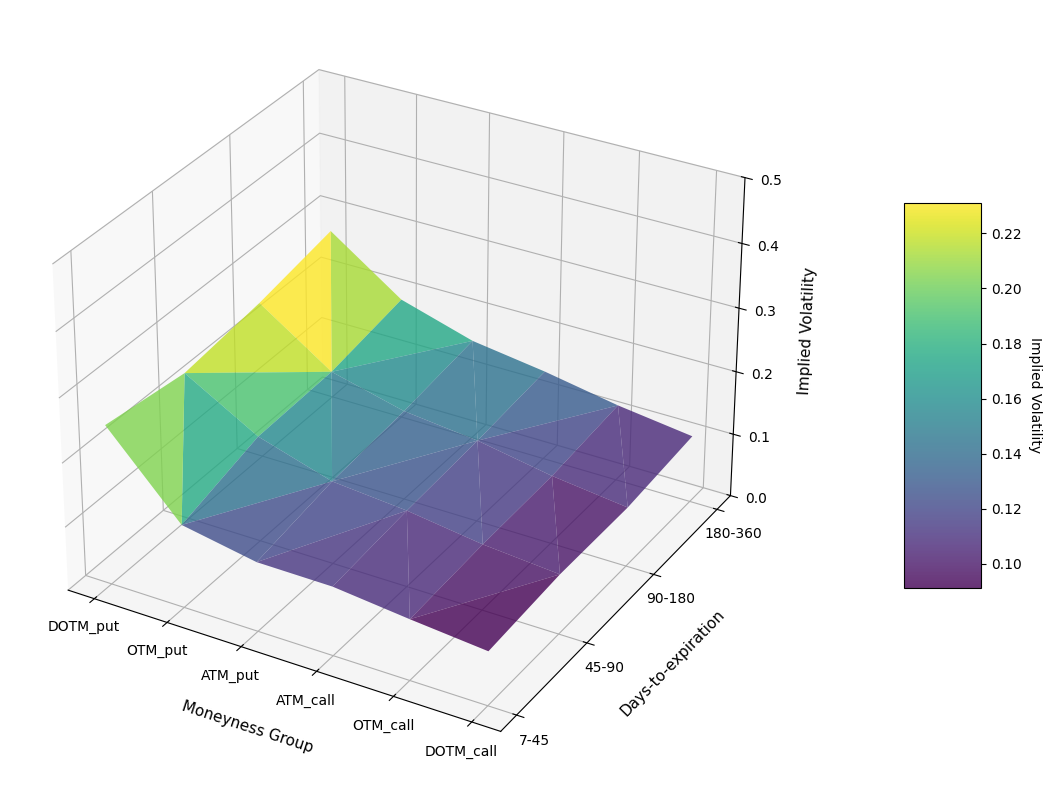

In [153]:
# Select one specific date for plotting
one_day = df_selected[df_selected['quote_date'] == '2015-02-27']

# Create maps to convert to values
m_map = {
    'DOTM_put': 1,
    'OTM_put': 2,
    'ATM_put': 3,
    'ATM_call': 4,
    'OTM_call': 5,
    'DOTM_call': 6}
t_map = {
    '7-45': 1,
    '45-90': 2,
    '90-180': 3,
    '180-360': 4}

# Add columns with numerical values
one_day['x_num'] = one_day['moneyness_group'].map(m_map)
one_day['y_num'] = one_day['maturity_group'].map(t_map)

# Plotting environment
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(projection='3d')

# Define x, y, z variables
X = one_day['x_num']
Y = one_day['y_num']
Z = one_day['iv']

# Plot the results
surf = ax.plot_trisurf(X, Y, Z,
                       cmap='viridis',
                       linewidth=0.1,
                       antialiased=True,
                       alpha=0.8)

# Plot colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, pad=0.1)
cbar.set_label('Implied Volatility', rotation=270,labelpad=15)

# Set x and y ticks and labels
ax.set_xticks(list(m_map.values()))
ax.set_xticklabels(list(m_map.keys()))
ax.set_yticks(list(t_map.values()))
ax.set_yticklabels(list(t_map.keys()))

# Set labels
ax.set_ylabel('Days-to-expiration', labelpad=14, fontsize=11)
ax.set_xlabel('Moneyness Group', labelpad=14, fontsize=11)
ax.set_zlabel('Implied Volatility', labelpad=10, fontsize=11)

# Limit the z-axis
ax.set_zlim(0, 0.5)

# Plot the results
plt.tight_layout()
plt.show()

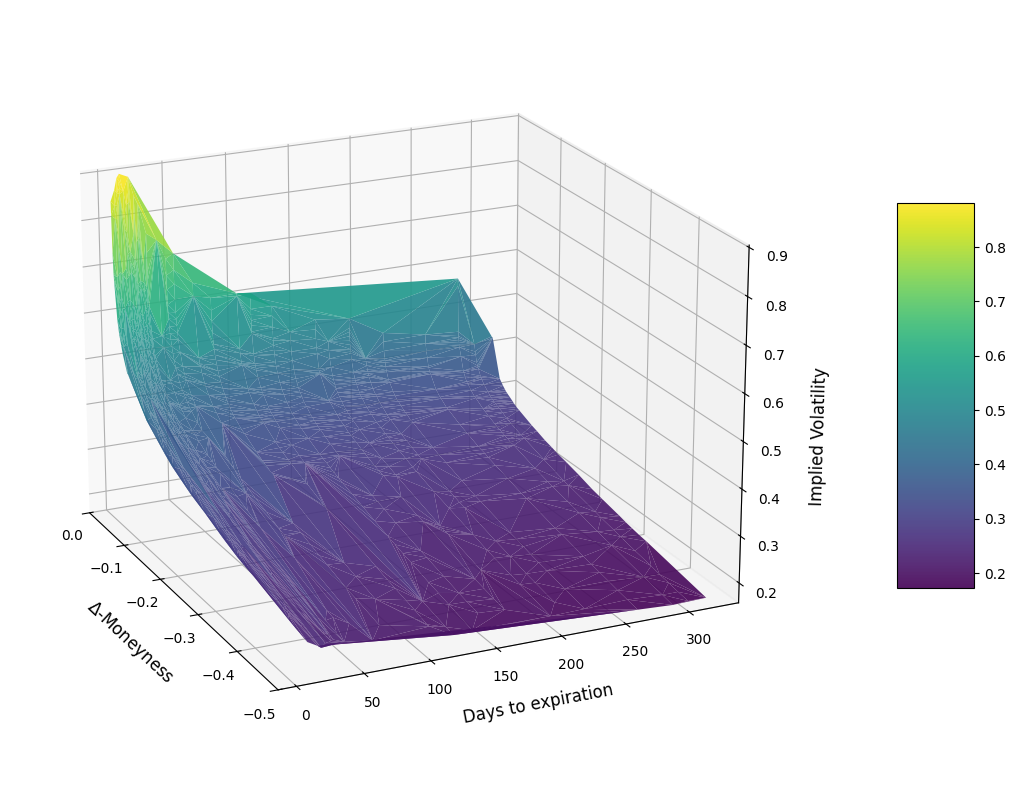

In [261]:
one_day = df_buckets[(df_buckets["quote_date"] == "2020-03-04") & (df_buckets["delta_fun"] > -0.5) & (df_buckets['option_type'] == 'put')]

moneyness = one_day['strike'] / one_day['underlying_last']
deltas = one_day['delta_fun']
ivs = one_day['iv']
dtes = one_day['dte']

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_trisurf(deltas, dtes, ivs,
                       cmap='viridis',
                       linewidth=0.1,
                       antialiased=True,
                       alpha=0.9)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, pad=0.1)

ax.set_xlabel(r'$\Delta$-Moneyness', labelpad=10, fontsize=12)
ax.set_ylabel('Days to expiration', labelpad=10, fontsize=12)
ax.set_zlabel('Implied Volatility', labelpad=10, fontsize=12)
ax.invert_xaxis()

ax.view_init(elev=20, azim=-25)

#ax.set_zlim(0, 1)
ax.set_xlim(0, -0.5)

plt.tight_layout()
plt.show()